<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-07-13 00:29:15--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  42.1MB/s    in 4.8s    

2026-07-13 00:29:20 (42.4 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 165.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 173.8 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 164.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 147.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.0 MB/s eta 0:00:00


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
print("Success!")

#### Connect to the SQLite database


In [6]:
import sqlite3
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [11]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('survey-data.sqlite')

QUERY = "SELECT COUNT(*) FROM main"

df = pd.read_sql_query(QUERY, conn)

print(df)

conn.close()

   COUNT(*)
0     65437


**Demo 2: List all tables**


In [12]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Display all tables in the database
QUERY = """
SELECT name AS Table_Name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql_query(QUERY, conn)
print("Tables in the database:")
print(tables)

# Count the number of rows in the main table
QUERY = """
SELECT COUNT(*) AS Total_Rows
FROM main;
"""

df = pd.read_sql_query(QUERY, conn)
print("\nNumber of rows in the main table:")
print(df)

# Close the connection
conn.close()

Tables in the database:
  Table_Name
0       main

Number of rows in the main table:
   Total_Rows
0       65437


**Demo 3: Group data by age**


In [13]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# SQL query
QUERY = """
SELECT Age, COUNT(*) AS count
FROM main
WHERE Age IS NOT NULL
GROUP BY Age
ORDER BY Age;
"""

# Execute the query and store the results in a DataFrame
df_age = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_age)

# Close the database connection
conn.close()

                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


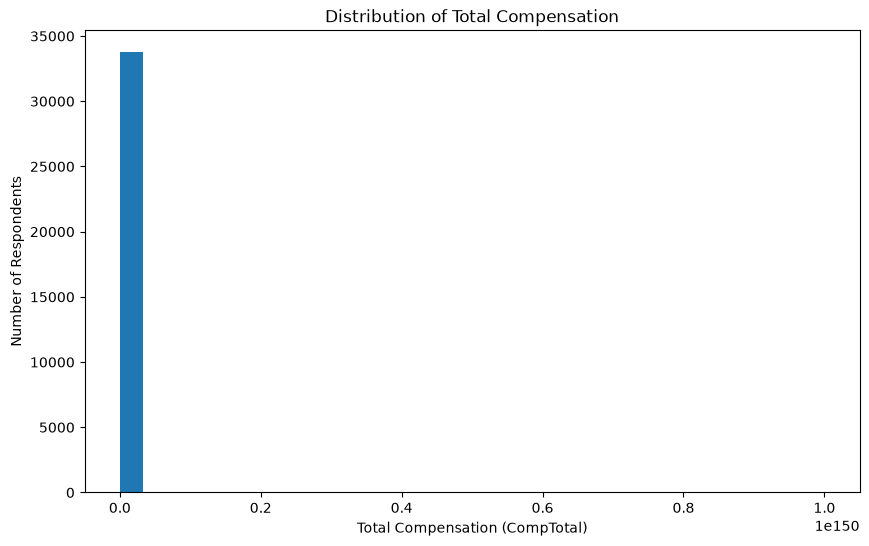

In [14]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# SQL query to retrieve CompTotal values
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL;
"""

# Load data into a DataFrame
df = pd.read_sql_query(QUERY, conn)

# Close the database connection
conn.close()

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['CompTotal'], bins=30)
plt.title('Distribution of Total Compensation')
plt.xlabel('Total Compensation (CompTotal)')
plt.ylabel('Number of Respondents')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


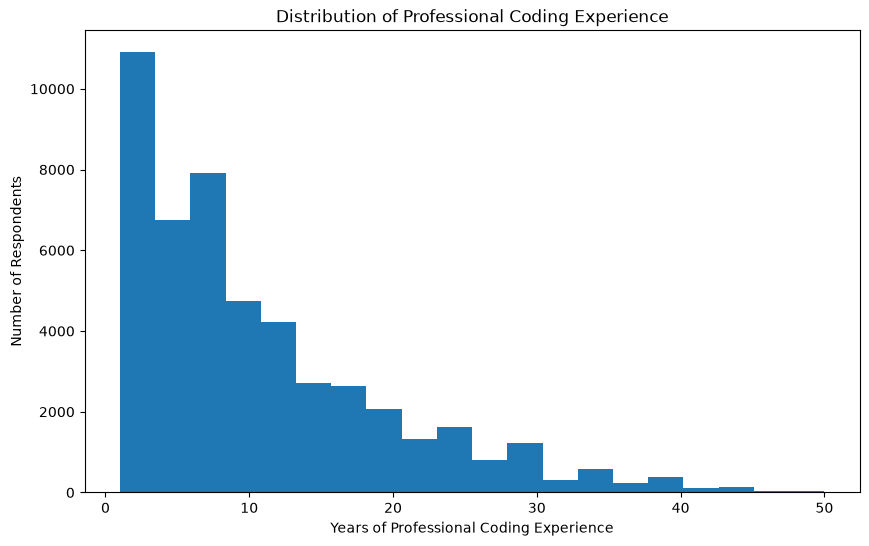

In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# SQL query to retrieve YearsCodePro values
QUERY = """
SELECT YearsCodePro
FROM main
WHERE YearsCodePro IS NOT NULL;
"""

# Load data into a DataFrame
df = pd.read_sql_query(QUERY, conn)

# Close the database connection
conn.close()

# Convert YearsCodePro to numeric (ignores non-numeric values)
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Remove any rows with missing values after conversion
df = df.dropna(subset=['YearsCodePro'])

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['YearsCodePro'], bins=20)
plt.title('Distribution of Professional Coding Experience')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Number of Respondents')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


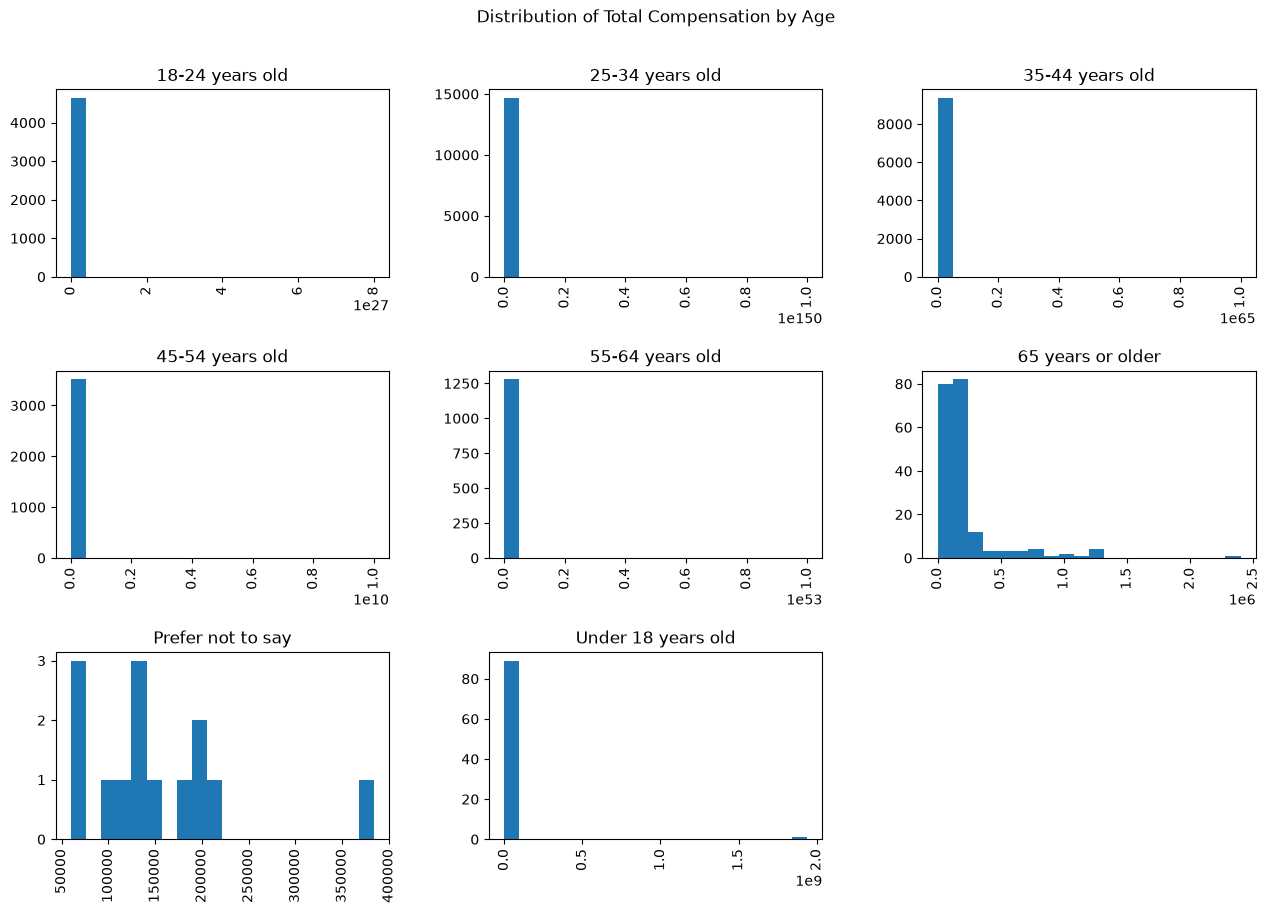

In [16]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# SQL query
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
  AND CompTotal IS NOT NULL;
"""

# Load data into a DataFrame
df = pd.read_sql_query(QUERY, conn)

# Close the connection
conn.close()

# Plot histogram grouped by Age
df.hist(column='CompTotal', by='Age', figsize=(15, 10), bins=20)

plt.suptitle('Distribution of Total Compensation by Age')
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


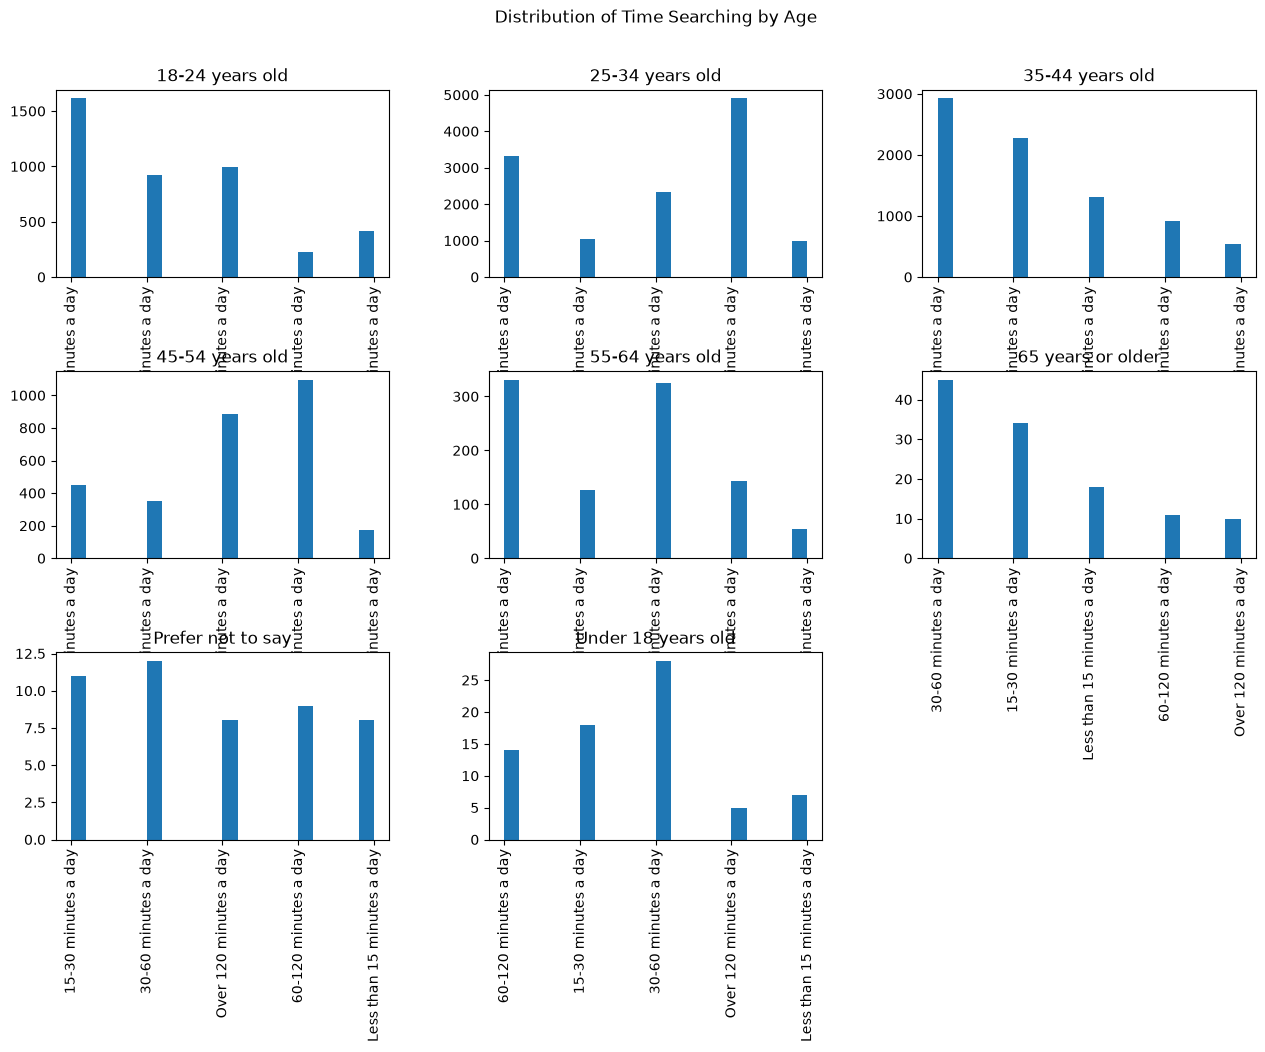

In [17]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# SQL query
QUERY = """
SELECT Age, TimeSearching
FROM main
WHERE Age IS NOT NULL
  AND TimeSearching IS NOT NULL;
"""

# Load data into a DataFrame
df = pd.read_sql_query(QUERY, conn)

# Close the connection
conn.close()

# Plot histograms grouped by Age
df.hist(column='TimeSearching', by='Age', figsize=(15, 10), bins=20)

plt.suptitle('Distribution of Time Searching by Age')
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


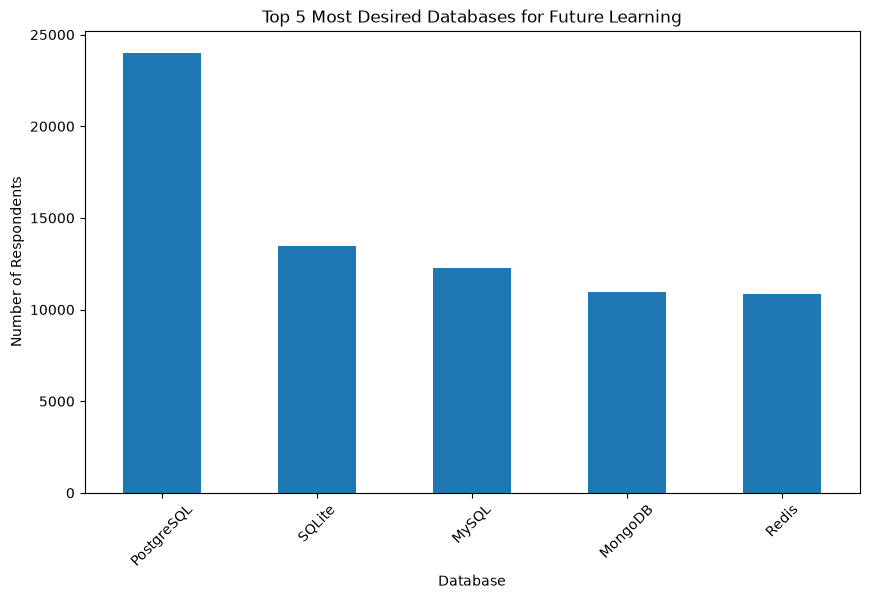

In [18]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# SQL query
QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL;
"""

# Load data into DataFrame
df = pd.read_sql_query(QUERY, conn)

# Close connection
conn.close()

# Split multiple database selections and count them
database_counts = (
    df['DatabaseWantToWorkWith']
    .str.split(';')
    .explode()
    .value_counts()
)

# Select top 5 databases
top_5_databases = database_counts.head(5)

# Plot the results
plt.figure(figsize=(10, 6))
top_5_databases.plot(kind='bar')

plt.title('Top 5 Most Desired Databases for Future Learning')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)

plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


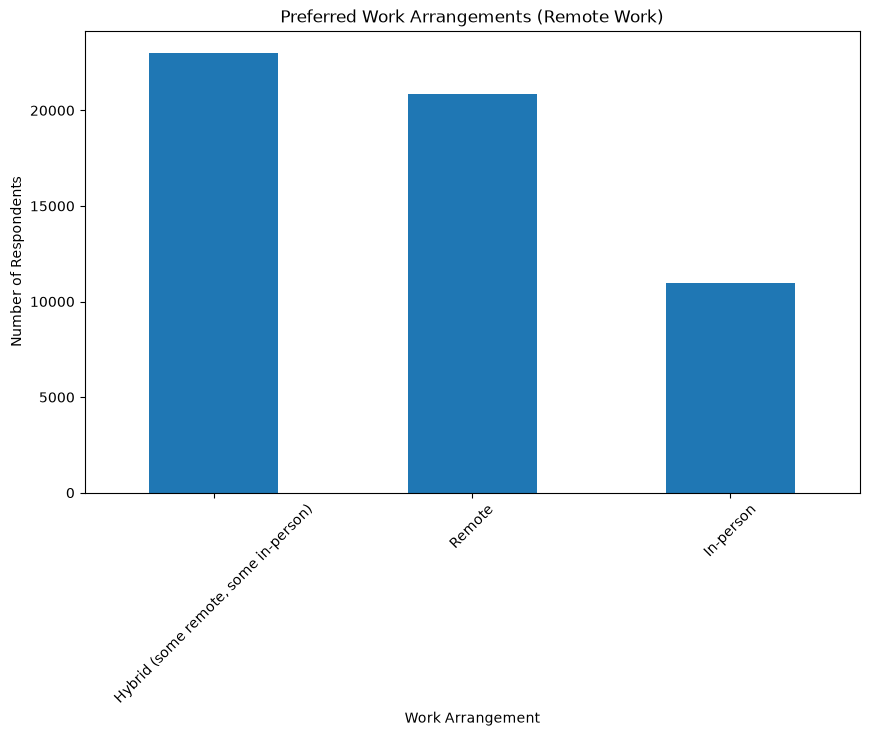

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# SQL query
QUERY = """
SELECT RemoteWork
FROM main
WHERE RemoteWork IS NOT NULL;
"""

# Load data into DataFrame
df = pd.read_sql_query(QUERY, conn)

# Close connection
conn.close()

# Count each remote work preference
remote_counts = df['RemoteWork'].value_counts()

# Plot histogram/bar chart
plt.figure(figsize=(10, 6))
remote_counts.plot(kind='bar')

plt.title('Preferred Work Arrangements (Remote Work)')
plt.xlabel('Work Arrangement')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)

plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


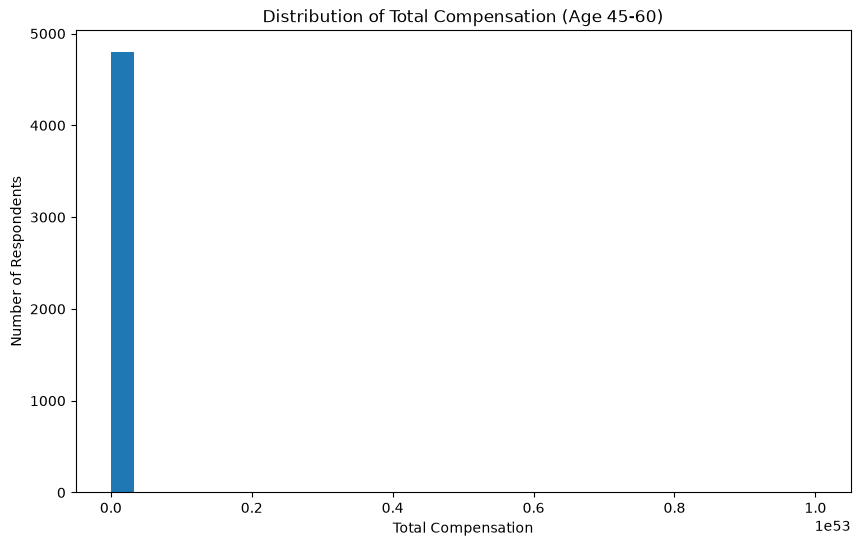

In [20]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# SQL query
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age BETWEEN 45 AND 60
  AND CompTotal IS NOT NULL;
"""

# Load data into DataFrame
df = pd.read_sql_query(QUERY, conn)

# Close connection
conn.close()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(df['CompTotal'], bins=30)

plt.title('Distribution of Total Compensation (Age 45-60)')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')

plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


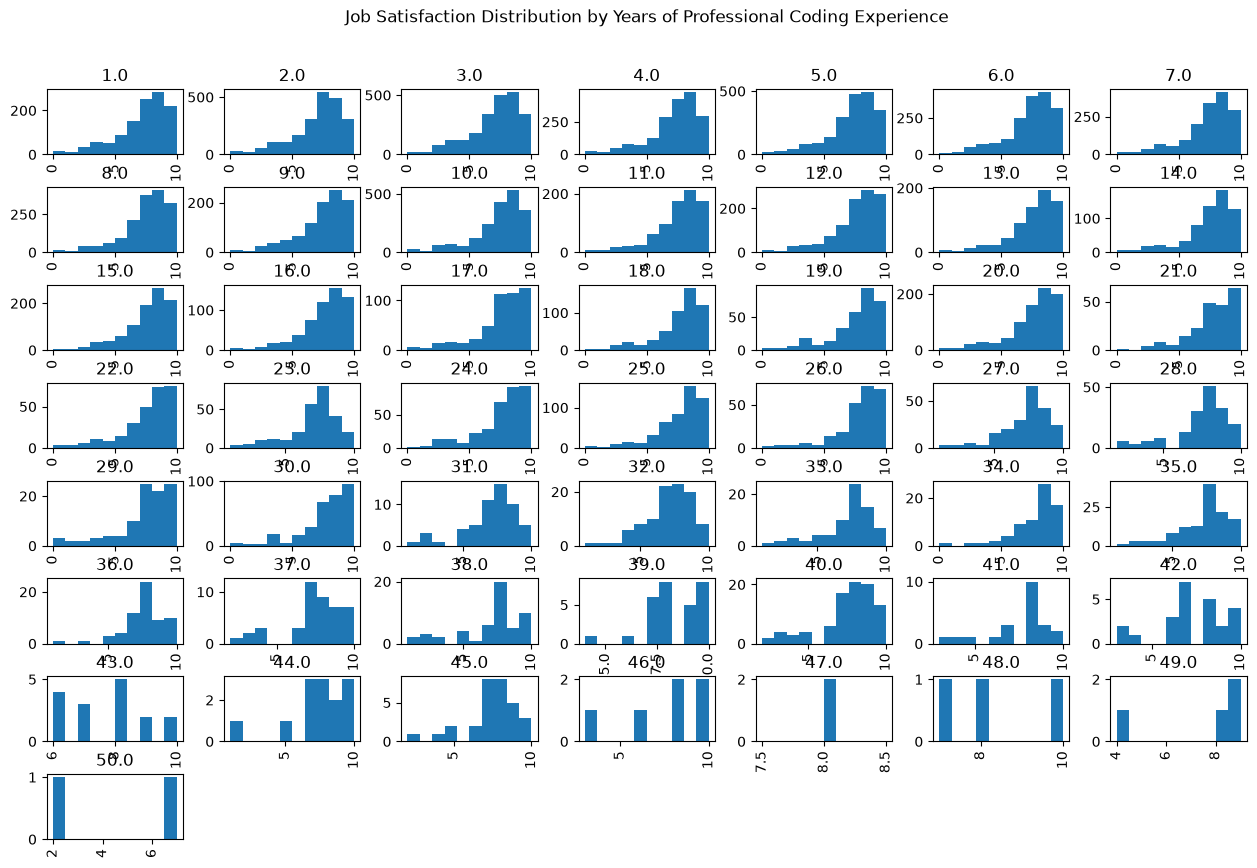

In [21]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# SQL query
QUERY = """
SELECT YearsCodePro, JobSat
FROM main
WHERE YearsCodePro IS NOT NULL
  AND JobSat IS NOT NULL;
"""

# Load data into DataFrame
df = pd.read_sql_query(QUERY, conn)

# Close connection
conn.close()

# Convert YearsCodePro to numeric
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Remove invalid values
df = df.dropna(subset=['YearsCodePro'])

# Plot histogram grouped by years of coding experience
df.hist(column='JobSat', by='YearsCodePro', figsize=(15, 10), bins=10)

plt.suptitle('Job Satisfaction Distribution by Years of Professional Coding Experience')
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [22]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
